In [1]:
import pandas as pd

# 1. Hàm đọc và trích xuất dữ liệu từ file humsavar.txt
def process_humsavar(file_path):
    print("1. Đang đọc file humsavar.txt...")
    with open(file_path, 'r') as f:
        lines = f.readlines()

    start_idx = next(i for i, line in enumerate(lines) if line.startswith('_________')) + 1

    records = []
    for line in lines[start_idx:]:
        parts = line.split()
        if len(parts) >= 6:
            records.append([
                parts[0], # gene
                parts[1], # protein_AC
                parts[3], # aa_change
                parts[4], # category
                parts[5], # dbSNP
                " ".join(parts[6:]) if len(parts) > 6 else "" # disease
            ])

    df = pd.DataFrame(records, columns=['gene', 'protein_AC', 'aa_change', 'category', 'dbSNP', 'disease'])

    print("2. Đang chuẩn hóa nhãn (Label)...")
    df = df[df['dbSNP'].str.startswith('rs', na=False)].copy()
    
    # Chuẩn hóa nhãn và loại bỏ nhãn US (Uncertain Significance)
    label_map = {'LP/P': 'patho', 'LB/B': 'benign'}
    df['label'] = df['category'].map(label_map)
    df = df.dropna(subset=['label'])
    
    print(f"Tổng số đột biến giữ lại: {len(df)}")
    return df

# 2. Thực thi và lưu tạm
file_path = r'D:\Study\AiTa_Lab_Research\humsavar.txt'
df_processed = process_humsavar(file_path)

# (Tùy chọn) Xuất danh sách rsID ra 1 file duy nhất nếu dùng VEP nội bộ
# df_processed['dbSNP'].to_csv('rsids_list.txt', index=False, header=False)

1. Đang đọc file humsavar.txt...
2. Đang chuẩn hóa nhãn (Label)...
Tổng số đột biến giữ lại: 64260


In [2]:
import glob
import os
import pandas as pd

print("1. Đang gộp 7 file từ thư mục Export...")
all_files = glob.glob(os.path.join(r'D:\Study\AiTa_Lab_Research\Export', '*.txt')) 

df_list = []
for file in all_files:
    # Đọc file, sử dụng tab (\t) hoặc dấu phẩy (,) tùy định dạng tải về
    try:
        df = pd.read_csv(file, sep='\t')
        if len(df.columns) == 1: # Nếu đọc nhầm bằng tab, thử lại bằng phẩy
            df = pd.read_csv(file, sep=',')
    except:
        df = pd.read_csv(file)
    df_list.append(df)
    
df_coords = pd.concat(df_list, ignore_index=True)

print("2. Trích xuất các cột tọa độ cần thiết...")
# Khắc phục lỗi: Thay vì gán cứng 4 cột, chúng ta sẽ trích xuất dựa trên tên cột thực tế của BioMart
col_mapping = {
    'Variant name': 'dbSNP',
    'Chromosome/scaffold name': 'chrom',
    'Chromosome/scaffold position start (bp)': 'pos',
    'Variant alleles': 'alleles'
}

# Chỉ giữ lại và đổi tên 4 cột quan trọng
df_coords = df_coords[list(col_mapping.keys())].rename(columns=col_mapping)

print("3. Đang tách Ref và Alt...")
def split_alleles(allele_str):
    if pd.isna(allele_str) or '/' not in str(allele_str):
        return pd.Series(['', ''])
    parts = str(allele_str).split('/')
    return pd.Series([parts[0], parts[1]]) 

df_coords[['ref', 'alt']] = df_coords['alleles'].apply(split_alleles)

# Chuẩn hóa tên nhiễm sắc thể (VD: '1' -> 'chr1')
df_coords['chrom'] = 'chr' + df_coords['chrom'].astype(str)

1. Đang gộp 7 file từ thư mục Export...
2. Trích xuất các cột tọa độ cần thiết...
3. Đang tách Ref và Alt...


In [3]:
print("4. Đang ghép tọa độ vào bảng dữ liệu chính...")
# Gộp 2 bảng dựa trên mã dbSNP
df_final = pd.merge(df_processed, df_coords[['dbSNP', 'chrom', 'pos', 'ref', 'alt']], on='dbSNP', how='inner')

# Dọn dẹp dữ liệu
df_final = df_final[(df_final['chrom'] != 'chrnan') & (df_final['ref'] != '')].copy()
df_final = df_final.drop_duplicates(subset=['dbSNP'])

print("5. Định dạng không gian dữ liệu...")
# Đưa 5 cột yêu cầu lên đầu tiên
cols_order = ['chrom', 'pos', 'ref', 'alt', 'label', 'dbSNP', 'gene', 'protein_AC', 'aa_change', 'disease']
df_final = df_final[cols_order]

print(f"HOÀN TẤT! Số lượng biến thể đạt chuẩn: {len(df_final)}")

# Lưu kết quả
df_final.to_csv('SwissProt_Orthogonal_Final.csv', index=False)
print("Đã lưu file: SwissProt_Orthogonal_Final.csv. Dữ liệu đã sẵn sàng cho Module 1!")

4. Đang ghép tọa độ vào bảng dữ liệu chính...
5. Định dạng không gian dữ liệu...
HOÀN TẤT! Số lượng biến thể đạt chuẩn: 61864
Đã lưu file: SwissProt_Orthogonal_Final.csv. Dữ liệu đã sẵn sàng cho Module 1!


KHỞI CHẠY EDA: SWISSPROT ORTHOGONAL VALIDATION

[1] DATASET OVERVIEW
Shape của dữ liệu: 61864 dòng, 10 cột

Thông tin các cột (Data types):
chrom         object
pos            int64
ref           object
alt           object
label         object
dbSNP         object
gene          object
protein_AC    object
aa_change     object
disease       object
dtype: object

Số lượng giá trị Unique mỗi cột:
chrom            30
pos           61831
ref              24
alt              24
label             2
dbSNP         61864
gene          12469
protein_AC    12485
aa_change     43525
disease        4221
dtype: int64

[2] DATA QUALITY
Số lượng Missing values (NaN):
chrom         0
pos           0
ref           0
alt           0
label         0
dbSNP         0
gene          0
protein_AC    0
aa_change     0
disease       0
dtype: int64

Số lượng dòng trùng lặp (Duplicates): 0
Số lượng đột biến có Nucleotide Ref dị biệt: 75
Số lượng đột biến có Nucleotide Alt dị biệt: 74

[3] UNIVARIATE ANALYSIS (Đang

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5456\3081089784.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2', ax=axes[0, 0], order=df['label'].value_counts().index)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5456\3081089784.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='chrom', palette='viridis', ax=axes[0, 1], order=present_chroms)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5456\3081089784.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ref', palette='muted

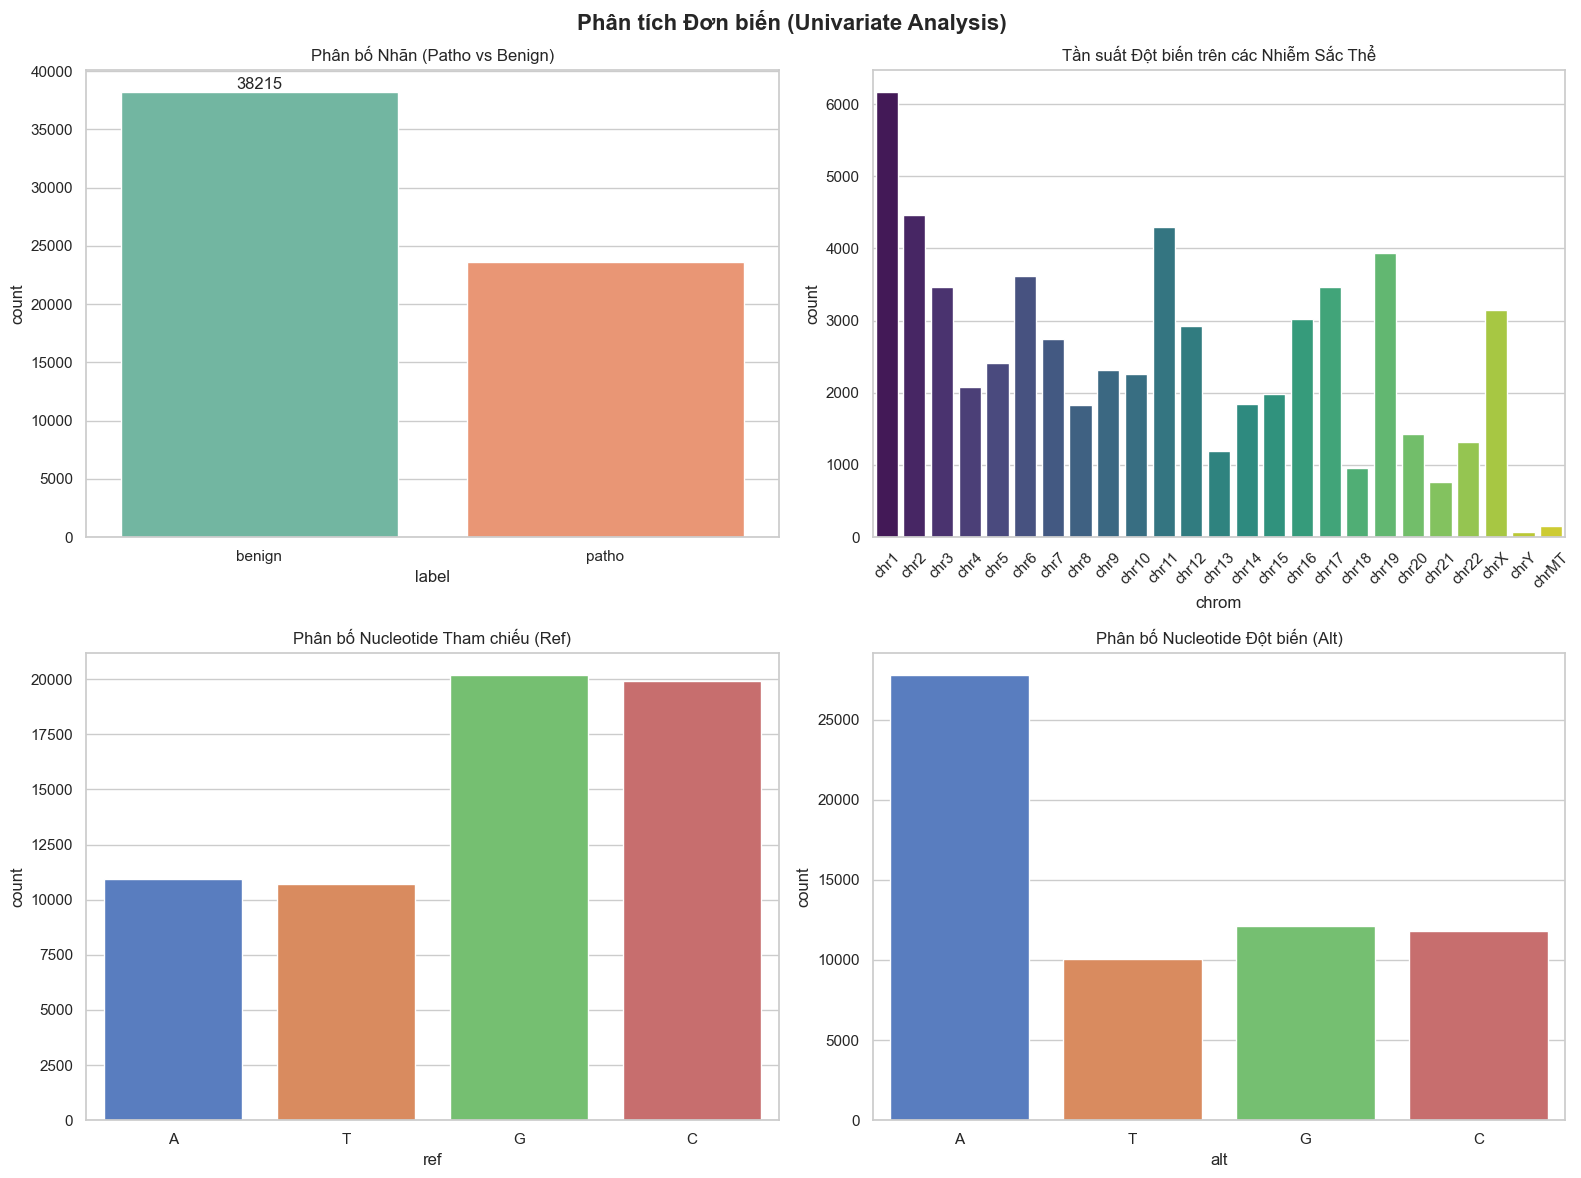


[4 & 5] BIVARIATE ANALYSIS (Đang xuất biểu đồ...)


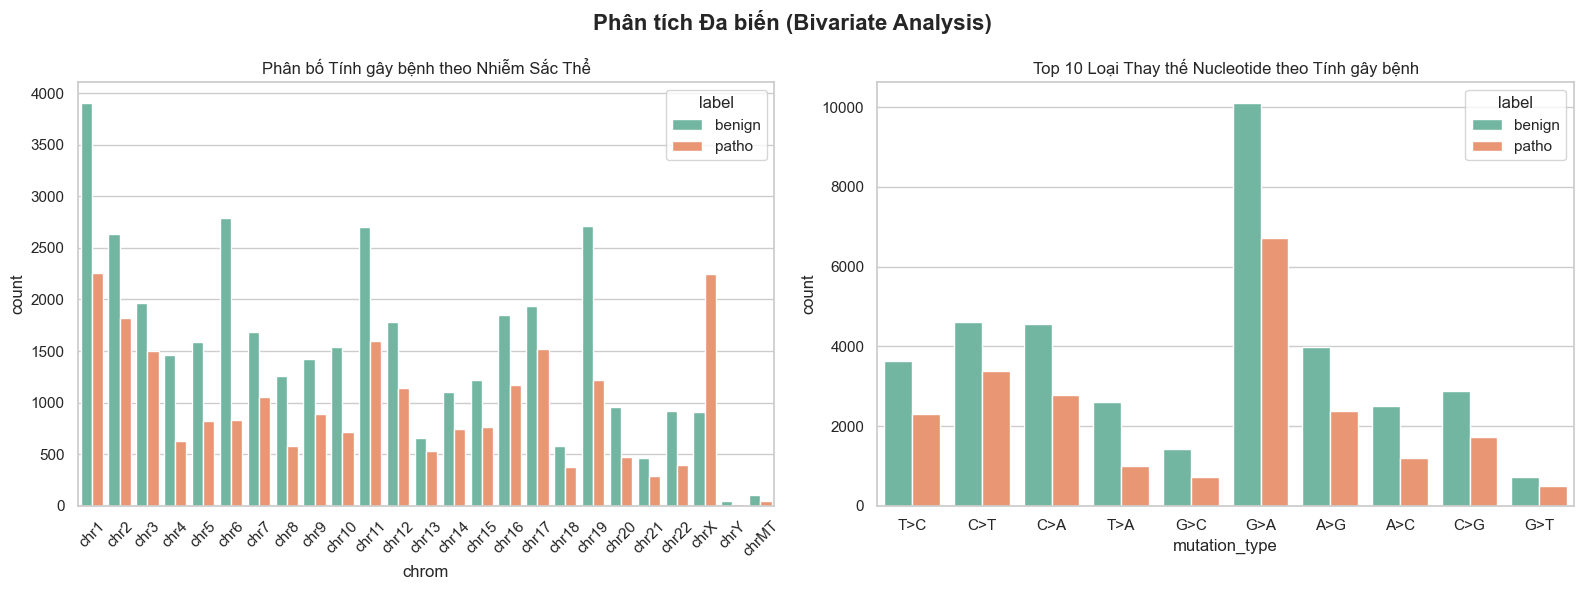


[7] DATA INSIGHTS & ANOMALIES
Top 5 Gen chứa nhiều đột biến Missense nhất trong tập dữ liệu:
gene
FBN1     282
F8       278
SCN1A    231
TTN      226
ABCA4    213
Name: count, dtype: int64

Top 5 Gen có tỷ lệ đột biến Pathogenic cao nhất:
gene
F8       270
FBN1     261
SCN1A    220
ABCA4    193
PAH      169
Name: count, dtype: int64

Tỷ lệ nhãn Pathogenic: 38.23%
-> Implications: Dữ liệu mất cân bằng (Imbalanced). Cần chú ý sử dụng thước đo MCC hoặc F1-score thay vì Accuracy.

[8] THỐNG KÊ CHI TIẾT THEO TỪNG GENE (GENE-LEVEL STATISTICS)
Bảng thống kê 10 gene có nhiều biến thể nhất:
 gene  total_variants  patho_variants  benign_variants  patho_percentage (%)
 FBN1             282             261               21                 92.55
   F8             278             270                8                 97.12
SCN1A             231             220               11                 95.24
  TTN             226               9              217                  3.98
ABCA4             213    

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# 0. TẢI DỮ LIỆU
print("="*50)
print("KHỞI CHẠY EDA: SWISSPROT ORTHOGONAL VALIDATION")
print("="*50)
df = pd.read_csv('SwissProt_Orthogonal_Final.csv')

# ---------------------------------------------------------
# 1. DATASET OVERVIEW
# ---------------------------------------------------------
print("\n[1] DATASET OVERVIEW")
print(f"Shape của dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nThông tin các cột (Data types):")
print(df.dtypes)
print("\nSố lượng giá trị Unique mỗi cột:")
print(df.nunique())

# ---------------------------------------------------------
# 2. DATA QUALITY
# ---------------------------------------------------------
print("\n[2] DATA QUALITY")
print("Số lượng Missing values (NaN):")
print(df.isnull().sum())
print(f"\nSố lượng dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

# Lọc các giá trị Invalid (Ví dụ: Ref/Alt có chứa các ký tự lạ không phải A, T, G, C)
valid_bases = ['A', 'T', 'G', 'C']
invalid_ref = df[~df['ref'].isin(valid_bases)]
invalid_alt = df[~df['alt'].isin(valid_bases)]
print(f"Số lượng đột biến có Nucleotide Ref dị biệt: {len(invalid_ref)}")
print(f"Số lượng đột biến có Nucleotide Alt dị biệt: {len(invalid_alt)}")

# ---------------------------------------------------------
# 3. UNIVARIATE ANALYSIS
# ---------------------------------------------------------
print("\n[3] UNIVARIATE ANALYSIS (Đang xuất biểu đồ...)")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Đơn biến (Univariate Analysis)', fontsize=16, fontweight='bold')

# Target Distribution (Nhãn)
sns.countplot(data=df, x='label', palette='Set2', ax=axes[0, 0], order=df['label'].value_counts().index)
axes[0, 0].set_title('Phân bố Nhãn (Patho vs Benign)')
axes[0, 0].bar_label(axes[0, 0].containers[0])

# Categorical Distribution: Chromosome
# Sắp xếp nhiễm sắc thể theo thứ tự logic (chr1 -> chr22, chrX, chrY)
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY', 'chrMT']
present_chroms = [c for c in chrom_order if c in df['chrom'].unique()]
sns.countplot(data=df, x='chrom', palette='viridis', ax=axes[0, 1], order=present_chroms)
axes[0, 1].set_title('Tần suất Đột biến trên các Nhiễm Sắc Thể')
axes[0, 1].tick_params(axis='x', rotation=45)

# Categorical Distribution: Reference Allele
sns.countplot(data=df, x='ref', palette='muted', ax=axes[1, 0], order=['A', 'T', 'G', 'C'])
axes[1, 0].set_title('Phân bố Nucleotide Tham chiếu (Ref)')

# Categorical Distribution: Alternate Allele
sns.countplot(data=df, x='alt', palette='muted', ax=axes[1, 1], order=['A', 'T', 'G', 'C'])
axes[1, 1].set_title('Phân bố Nucleotide Đột biến (Alt)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4, 5, 6. OUTLIER, BIVARIATE, CORRELATION (GHI CHÚ)
# ---------------------------------------------------------
# Lưu ý: Các phân tích số học tiêu chuẩn không áp dụng cho tọa độ vật lý.
# Thay vào đó, chúng ta phân tích chéo (Bivariate) giữa Label và các thuộc tính sinh học.

print("\n[4 & 5] BIVARIATE ANALYSIS (Đang xuất biểu đồ...)")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân tích Đa biến (Bivariate Analysis)', fontsize=16, fontweight='bold')

# Bivariate: Chromosome ↔ Label
sns.countplot(data=df, x='chrom', hue='label', palette='Set2', ax=axes[0], order=present_chroms)
axes[0].set_title('Phân bố Tính gây bệnh theo Nhiễm Sắc Thể')
axes[0].tick_params(axis='x', rotation=45)

# Bivariate: Loại đột biến Nucleotide (Ref -> Alt) ↔ Label
df['mutation_type'] = df['ref'] + '>' + df['alt']
top_mutations = df['mutation_type'].value_counts().head(10).index
sns.countplot(data=df[df['mutation_type'].isin(top_mutations)], x='mutation_type', hue='label', palette='Set2', ax=axes[1])
axes[1].set_title('Top 10 Loại Thay thế Nucleotide theo Tính gây bệnh')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. DATA INSIGHTS
# ---------------------------------------------------------
print("\n[7] DATA INSIGHTS & ANOMALIES")

# Pattern: Top Gen có nhiều đột biến nhất
print("Top 5 Gen chứa nhiều đột biến Missense nhất trong tập dữ liệu:")
print(df['gene'].value_counts().head(5))

# Pattern: Top Gen chứa nhiều đột biến Gây bệnh (Pathogenic) nhất
patho_df = df[df['label'] == 'patho']
print("\nTop 5 Gen có tỷ lệ đột biến Pathogenic cao nhất:")
print(patho_df['gene'].value_counts().head(5))

# Anomalies / Data Integrity: Đánh giá tỷ lệ mất cân bằng dữ liệu
patho_count = len(patho_df)
benign_count = len(df[df['label'] == 'benign'])
ratio = patho_count / (patho_count + benign_count)
print(f"\nTỷ lệ nhãn Pathogenic: {ratio:.2%}")
if 0.4 <= ratio <= 0.6:
    print("-> Implications: Dữ liệu khá cân bằng (Balanced). Tốt cho việc huấn luyện và đánh giá.")
else:
    print("-> Implications: Dữ liệu mất cân bằng (Imbalanced). Cần chú ý sử dụng thước đo MCC hoặc F1-score thay vì Accuracy.")

# ---------------------------------------------------------
# 8. GENE-LEVEL STATISTICS (Thống kê theo Gene)
# ---------------------------------------------------------
print("\n[8] THỐNG KÊ CHI TIẾT THEO TỪNG GENE (GENE-LEVEL STATISTICS)")

# Nhóm dữ liệu theo gene và tính toán các chỉ số
gene_stats = df.groupby('gene').agg(
    total_variants=('label', 'count'),
    patho_variants=('label', lambda x: (x == 'patho').sum()),
    benign_variants=('label', lambda x: (x == 'benign').sum())
).reset_index()

# Tính phần trăm đột biến gây bệnh trên từng gene
gene_stats['patho_percentage (%)'] = (gene_stats['patho_variants'] / gene_stats['total_variants']) * 100

# Làm tròn phần trăm để hiển thị đẹp hơn
gene_stats['patho_percentage (%)'] = gene_stats['patho_percentage (%)'].round(2)

# Tính trung bình cộng phần trăm bệnh trên tất cả các gene
average_patho_percentage = gene_stats['patho_percentage (%)'].mean()

# Sắp xếp theo tổng số lượng đột biến giảm dần để quan sát các gen phổ biến nhất
gene_stats = gene_stats.sort_values(by='total_variants', ascending=False)

print("Bảng thống kê 10 gene có nhiều biến thể nhất:")
print(gene_stats.head(10).to_string(index=False))

print(f"\n=> Trung bình cộng tỷ lệ đột biến gây bệnh trên tất cả các gene: {average_patho_percentage:.2f}%")